In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import sys
sys.path.append("/Users/tdinelli/Documents/GitHub/diffPLOG2TROE")
from diffPLOG2TROE.rate_constants import FallOff
from diffPLOG2TROE.rate_constants import Plog
from diffPLOG2TROE.plog_refitter import PlogRefitter

import matplotlib.pyplot as plt
from matplotlib import rcParams

import numpy as np
import seaborn as sns
rcParams["text.usetex"] = True

In [28]:
starting_plog = {
    "name": "NH2+H=NH3",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [1.00000e-01, 1.21300e+27, -4.95900e+00, 2.80709e+03],
            [1.00000e+00, 5.86700e+27, -4.86700e+00, 3.10796e+03],
            [1.00000e+01, 3.31400e+28, -4.79800e+00, 3.83238e+03],
            [1.00000e+02, 4.51200e+28, -4.56300e+00, 4.72319e+03],
        ]
    },
}

param_config = {
    "A_high": {"optimize": False, "value": 1.50e+14},
    "n_high": {"optimize": False, "value": 0.167},
    "E_high": {"optimize": False, "value": 0.0},
    # "A_low": {"optimize": True, "value": 3.14791725e+29},
    # "n_low": {"optimize": True, "value": -3.78548709e+00},
    # "E_low": {"optimize": True, "value": 2.23670630e+03},
    # "A": {"optimize": True, "value": 2.44457187e-01},
    # "T3": {"optimize": True, "value": 1.68097665e+02},
    # "T1": {"optimize": True, "value": 1.e+10},
    # "T2": {"optimize": True, "value": 1.e+10},
    
}

refitter = PlogRefitter(
    starting_plog,
    T_range=(500, 2500),
    P_range=(0.1, 100),
    n_T=300,
    n_P=300,
    param_config=param_config
)

nlopt_options = {
    "algorithm": "NLOPT_LD_TNEWTON_PRECOND_RESTART",  # Trust-region Newton with preconditioner
    # "algorithm": "NLOPT_LD_LBFGS",  # LBFGS
    "max_eval": 20000,
    "ftol_rel": 1e-15,
    "xtol_rel": 1e-15,
    "steps_file": 100
}
initial_troe = refitter.fit(loss_type="rel-abs", nlopt_options=nlopt_options)

print(FallOff(initial_troe))

Plog 2 TROE refitter
 Temperature range [K]: (500, 2500)
 Pressure range [atm]: (0.1, 100)

Parameters configuration:
  A_low: optimizing from default initial value
  n_low: optimizing from default initial value
  E_low: optimizing from default initial value
  A_high: fixed at 1.50000e+14
  n_high: fixed at 1.67000e-01
  E_high: fixed at 0.00000e+00
  A: optimizing from default initial value
  T3: optimizing from default initial value
  T1: optimizing from default initial value
  T2: optimizing from default initial value


Starting hybrid optimization
First guess estimate of the parameters:
  High pressure limit (A, n, Ea): 1.500e+14, 0.167, 0.000e+00
  Low pressure limit (A, n, Ea): 1.213e+27, -4.959, 2.807e+03
  Troe parameters (A, T3, T1, T2): 0.500, 1.050e+03, 3.000e+02, 2.250e+03

  Step 0: loss = 1.359470e+01
  Gradient norm: 7.271676e+00
  Step 100: loss = 1.009793e-01
  Gradient norm: 1.873988e-02
  Step 200: loss = 6.181359e-02
  Gradient norm: 1.956332e-01
  Step 300: loss = 

NH2+H=NH3		1.50000e+14 0.16700 0.00000e+00
 LOW  / 		5.84309e+29 -3.84952 2.70450e+03 /
 TROE / 5.37948e-01 2.26528e+03 3.11309e+01 7.23545e+03 /


0.8426840076942125
1.0875722333497435
0.9994924649547712


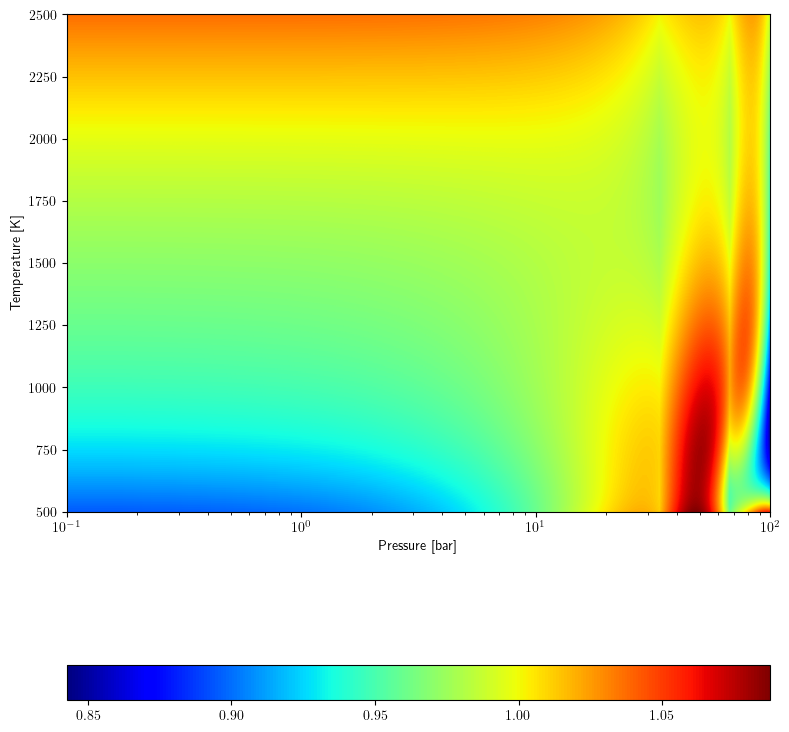

In [34]:
T_range = jnp.linspace(500, 2500, 1000)
P_range = jnp.logspace(jnp.log10(0.1), jnp.log10(100), 1000)

T_mesh, P_mesh = jnp.meshgrid(T_range, P_range)

falloff = FallOff(initial_troe)
plog = Plog(starting_plog)
k_falloff_map = falloff.kinetic_constant(T_range, P_range)
k_plog_map = plog.kinetic_constant(T_range, P_range)
    
ratio = k_falloff_map.T / k_plog_map.T

plt.figure(figsize=(8, 8))
im = plt.imshow(
    ratio,
    origin='lower',
    aspect='auto',
    extent=[P_range[0], P_range[-1], T_range[0], T_range[-1]],
    cmap='jet'
)
    
plt.xscale('log')
plt.xlabel('Pressure [bar]', fontweight='bold')
plt.ylabel('Temperature [K]', fontweight='bold')
    
cbar = plt.colorbar(im, orientation='horizontal', pad=0.2)
# cbar.set_label(r'$\mathbf{k_{\text{TROE}} / k_{\text{PLOG}}}$')

print(jnp.min(ratio))
print(jnp.max(ratio))
print(jnp.mean(ratio))

plt.tight_layout()
plt.show()

In [ ]:
starting_plog = {
    "name": "NH2+H=NH3",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [1.00000e-01, 1.21300e+27, -4.95900e+00, 2.80709e+03],
            [1.00000e+00, 5.86700e+27, -4.86700e+00, 3.10796e+03],
            [1.00000e+01, 3.31400e+28, -4.79800e+00, 3.83238e+03],
            [1.00000e+02, 4.51200e+28, -4.56300e+00, 4.72319e+03],
        ]
    },
}

param_config = {
    "A_high": {"optimize": False, "value": 1.50e+14},
    "n_high": {"optimize": False, "value": 0.167},
    "E_high": {"optimize": False, "value": 0.0},
    # "A_low": {"optimize": True, "value": 3.14791725e+29},
    # "n_low": {"optimize": True, "value": -3.78548709e+00},
    # "E_low": {"optimize": True, "value": 2.23670630e+03},
    # "A": {"optimize": True, "value": 2.44457187e-01},
    # "T3": {"optimize": True, "value": 1.68097665e+02},
    # "T1": {"optimize": True, "value": 6.38945433e+29},
    # "T2": {"optimize": True, "value": 1.86787948e+29},
    
}

refitter = PlogRefitter(
    starting_plog,
    T_range=(500, 2500),
    P_range=(0.1, 100),
    n_T=300,
    n_P=300,
    param_config=param_config
)

optax_options = {
    "algorithm": "adam",
    "learning_rate": 5e-4,  # Lower base learning rate
    "max_steps": 100000,
    "patience": 3000,      # Stop earlier if not improving
    "clip_norm": 1.0,      # Try different gradient clipping
    "use_scheduler": True,
    "schedule_type": "exponential",  # Try exponential instead of cosine
    "decay_rate": 0.95,    # Slower decay
    "ftol": 1e-8,
    "steps_file": 1000
}
initial_troe = refitter.fit(loss_type="rel-abs", optax_options=optax_options)

print(FallOff(initial_troe))

In [ ]:
T_range = jnp.linspace(500, 2500, 1000)
P_range = jnp.logspace(jnp.log10(0.1), jnp.log10(100), 1000)

T_mesh, P_mesh = jnp.meshgrid(T_range, P_range)

falloff = FallOff(initial_troe)
plog = Plog(starting_plog)
k_falloff_map = falloff.kinetic_constant(T_range, P_range)
k_plog_map = plog.kinetic_constant(T_range, P_range)
    
ratio = k_falloff_map.T / k_plog_map.T

plt.figure(figsize=(8, 8))
im = plt.imshow(
    ratio,
    origin='lower',
    aspect='auto',
    extent=[P_range[0], P_range[-1], T_range[0], T_range[-1]],
    cmap='viridis'
)
    
plt.xscale('log')
plt.xlabel('Pressure [bar]', fontweight='bold')
plt.ylabel('Temperature [K]', fontweight='bold')
    
cbar = plt.colorbar(im, orientation='horizontal', pad=0.2)
# cbar.set_label(r'$\mathbf{k_{\text{TROE}} / k_{\text{PLOG}}}$')

print(jnp.min(ratio))
print(jnp.max(ratio))
print(jnp.mean(ratio))

plt.tight_layout()
plt.show()